**Step 1: Importing the Libraries**

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pickle

import warnings
warnings.filterwarnings("ignore")

**Step 2: Read the Dataset**

In [33]:
application = pd.read_csv("application_record.csv")
credit = pd.read_csv("credit_record.csv")

**Step 3 : Univariate Analysis**

Number of people working status :
OCCUPATION_TYPE
Laborers                 78240
Core staff               43007
Sales staff              41098
Managers                 35487
Drivers                  26090
High skill tech staff    17289
Accountants              15985
Medicine staff           13520
Cooking staff             8076
Security staff            7993
Cleaning staff            5845
Private service staff     3456
Low-skill Laborers        2140
Secretaries               2044
Waiters/barmen staff      1665
Realty agents             1041
HR staff                   774
IT staff                   604
Name: count, dtype: int64


<Axes: xlabel='OCCUPATION_TYPE', ylabel='count'>

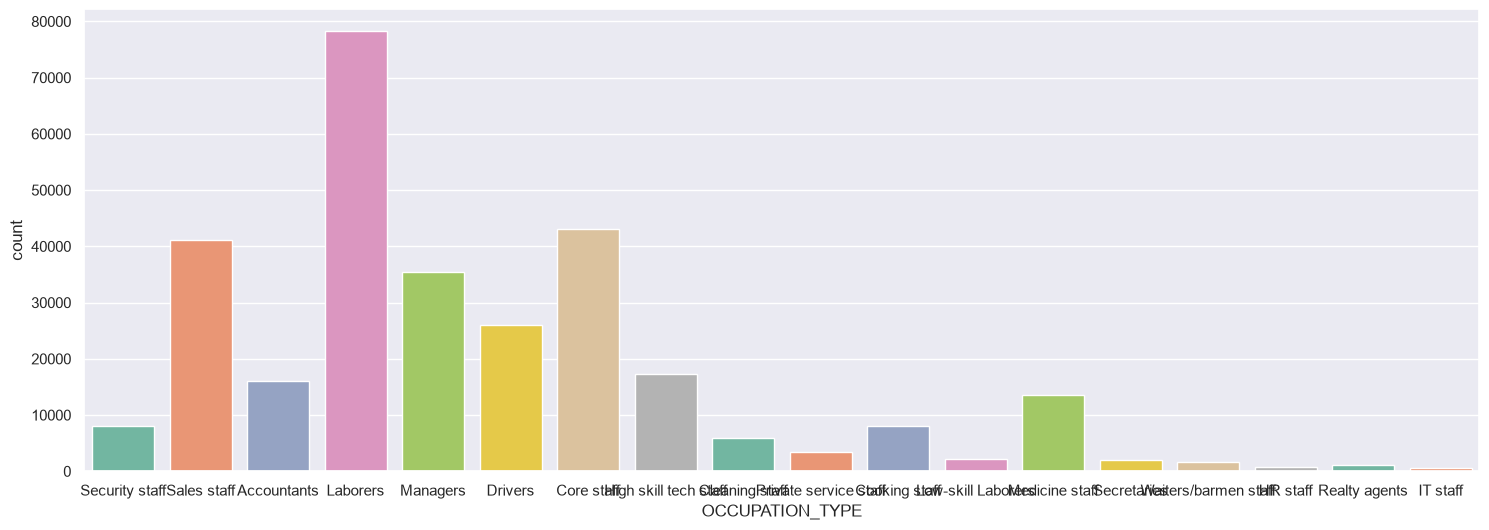

In [34]:
print("Number of people working status :")
print(application['OCCUPATION_TYPE'].value_counts())

sns.set(rc={'figure.figsize':(18,6)})

sns.countplot(x='OCCUPATION_TYPE', data=application, palette='Set2')

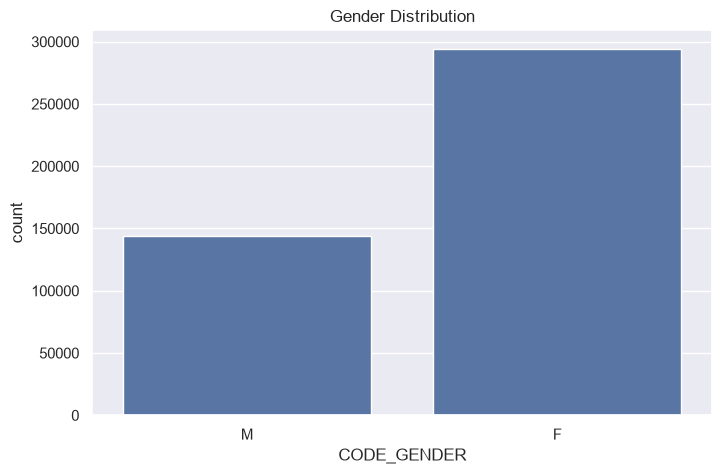

In [35]:
plt.figure(figsize=(8,5))
sns.countplot(x="CODE_GENDER", data=application)
plt.title("Gender Distribution")
plt.show()

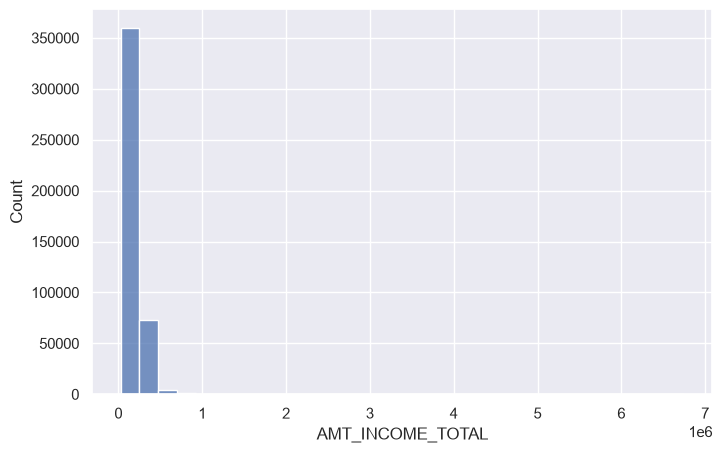

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(application["AMT_INCOME_TOTAL"], bins=30)
plt.show()

**Step 4 : Multivariate Analysis**

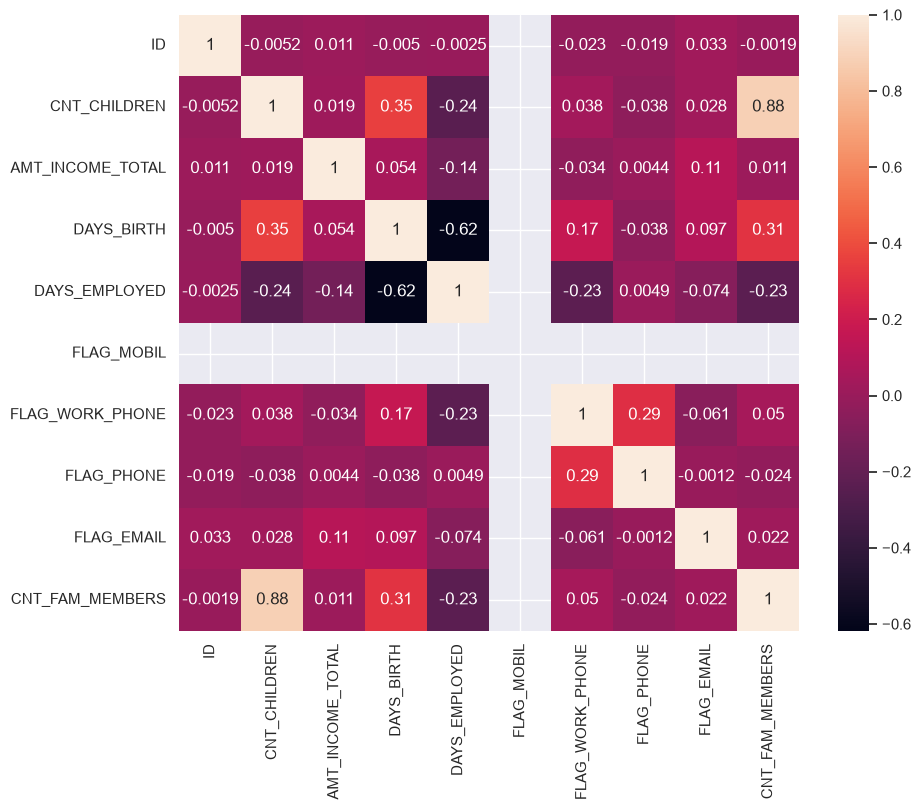

In [37]:
plt.figure(figsize=(10,8))
sns.heatmap(application.corr(numeric_only=True), annot=True)
plt.show()

**Step 5 : Descriptive Analysis**

In [ ]:
application.describe()

**Step 6: Merge Dataset**

In [ ]:
df = application.merge(credit, on="ID")

**Step 4: Check Dataset**

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df.info()

**Step 5: Create Target Column**

In [ ]:
def status_binary(x):
    if x in ['0','X','C']:
        return 1
    else:
        return 0

df["STATUS_BIN"] = df["STATUS"].apply(status_binary)

**Step 7: Keep Only Required Columns**

In [ ]:
df = df[
[
'CODE_GENDER',
'FLAG_OWN_CAR',
'FLAG_OWN_REALTY',
'CNT_CHILDREN',
'AMT_INCOME_TOTAL',
'NAME_INCOME_TYPE',
'NAME_EDUCATION_TYPE',
'NAME_FAMILY_STATUS',
'NAME_HOUSING_TYPE',
'DAYS_BIRTH',
'DAYS_EMPLOYED',
'CNT_FAM_MEMBERS',
'STATUS_BIN'
]
]

**Step 8: Checking Missing Values**

In [ ]:
df.isnull().sum()

**Step 9: Encode Categorical Columns**

In [ ]:
le_gender = LabelEncoder()
le_car = LabelEncoder()
le_realty = LabelEncoder()
le_income = LabelEncoder()
le_education = LabelEncoder()
le_family = LabelEncoder()
le_house = LabelEncoder()

df["CODE_GENDER"] = le_gender.fit_transform(df["CODE_GENDER"])
df["FLAG_OWN_CAR"] = le_car.fit_transform(df["FLAG_OWN_CAR"])
df["FLAG_OWN_REALTY"] = le_realty.fit_transform(df["FLAG_OWN_REALTY"])

df["NAME_INCOME_TYPE"] = le_income.fit_transform(df["NAME_INCOME_TYPE"])

df["NAME_EDUCATION_TYPE"] = le_education.fit_transform(df["NAME_EDUCATION_TYPE"])

df["NAME_FAMILY_STATUS"] = le_family.fit_transform(df["NAME_FAMILY_STATUS"])

df["NAME_HOUSING_TYPE"] = le_house.fit_transform(df["NAME_HOUSING_TYPE"])

**Step 10: Spliting Features**

In [ ]:
X = df.drop("STATUS_BIN", axis=1)

y = df["STATUS_BIN"]

**Step 11: Splitting into training and test sets**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

**(Optional): Balance the Data**

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

**Step 12 : Building Model (Random Forest)**

In [ ]:
# Model Initialization
rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Model Training
rf_model.fit(X_train, y_train)

**Step 13 : Model Prediction**

In [ ]:
y_pred = rf_model.predict(X_test)


**Step 14: Model Evaluation**

In [ ]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

**Step 15:Save Model**

Saving your trained model to disk using Python’s pickle library:
import pickle  
Loads the pickle module, which is used for serializing (saving) and deserializing (loading) Python objects.

pickle.dump(rf_model, open("model.pkl", "wb"))  
👉 This takes your trained model (rf_model) and writes it into a file called model.pkl.

"wb" means write in binary mode.

dump serializes the model object into bytes and stores it in that file.

Later, you can load it back with pickle.load(open("model.pkl", "rb")).

print("✅ Model Saved Successfully")  
Just a confirmation message to let you know the model has been saved.

It allows you to reuse the trained model without retraining it every time.


In [ ]:
import pickle

pickle.dump(rf_model, open("model.pkl", "wb"))

print("✅ Model Saved Successfully")

In [ ]:
model = pickle.load(open("model.pkl", "rb"))

prediction = model.predict(X_test.iloc[[0]])

print("Prediction:", prediction)
print("Actual:", y_test.iloc[0])